In [2]:

import os

import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from scipy.signal import welch
#import regex as reg
from sklearn.pipeline import Pipeline
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import mne
import numpy as np
from scipy.stats import iqr
import warnings
from models.graph_sage import GraphSAGE
import torch
from torch_geometric.data import Data
from utils.train_loop import train_riemannian_gnn
from models.RiemannianGAT import RiemannianGAT
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

mne.set_log_level('ERROR')   # silence MNE

warnings.filterwarnings("ignore")  # silence warnings

In [3]:
latest_channel_list = [
    # Left sensorimotor area channels
    'E29', 'E30', 'E35', 'E36', 'E41', 'E42',
    # Right sensorimotor area channels
    'E103', 'E104', 'E109', 'E110', 'E115', 'E116',
    # Mid-parietal & bilateral parietal
    'E62', 'E67', 'E72', 'E77'
 ]

new_latest = ['E24', 'E124', 'E36', 'E104', 'E47','E52', 'E60', 'E67', 'E72', 'E77', 'E85', 'E92', 'E98', 'E62','E70', 'E75', 'E83','E58','E96','E90','E65','E69','E74','E82','E89'
              ,'E1', 'E32','E14', 'E21']

bad_channels = ['E17', 'E38', 'E94', 'E113', 'E119', 'E121', 'E125', 'E128', 'E73', 'E81', 'E88', 'E43', 'E44', 'E120', 'E114','E127', 'E126',
                 'E68', 'E23', 'E3','E49','E48', "E8", "E25",
     "E56", "E63", "E99", "E107"]


                 
#bad_channels = ['E48', 'E119', 'E49', 'E113', 'E94', 'E68', 'E23', 'E3', 'E126', 'E127']



#label_dict = {'OBBA': 0, 'OBBY': 1, 'OBDO': 2, 'OBMO': 3, 'OBSI':4}
label_dict = {'IMBA': 0,'IMBY': 1,'IMSI':2 } # banana, baby, sitar
directions = ['IMBA', 'IMBY', 'IMSI']

#directions = ['OBBA', 'OBBY', 'OBDO', 'OBDO','OBSI']  # Left, Right, Up, Down

In [4]:
channel_tuple = (new_latest, bad_channels)

In [5]:

class preprocessing_pipeline:
    def __init__(self, filename, *channel_tuple, 
                 l_freq=0.5, h_freq=100.0, notch_freq=50.0, fs=500.0, time_window=1.0,
                 apply_ica=False, remove_muscle=False,
                 eog_vertical_chs=('E14', 'E21'), eog_horizontal_chs=('E1', 'E32')):
        
        self.filename = filename
        self.l_freq = l_freq
        self.h_freq = h_freq
        self.notch_freq = notch_freq
        self.time_window = time_window
        self.fs = fs
        self.active_channels = channel_tuple[0]
        self.bad_channels = channel_tuple[1]
        self.apply_ica = apply_ica
        self.remove_muscle = remove_muscle
        self.eog_vertical_chs = list(eog_vertical_chs)
        self.eog_horizontal_chs = list(eog_horizontal_chs)
        self.ica = None  # Store for inspection later

        self.raw = self.file_process()
        self.annotations = self.raw.annotations

    def file_process(self):
        raw = mne.io.read_raw_egi(self.filename, preload=True)
        
        if 'VREF' in raw.ch_names:
            raw.drop_channels(['VREF'])


        
        raw.pick('eeg')
        raw.pick_channels(self.active_channels)

        # if self.bad_channels:
        #     raw.drop_channels([ch for ch in self.bad_channels if ch in raw.ch_names])

  

        # Filter BEFORE ICA (ICA needs broadband signal to detect artifacts)
        # Use 1Hz high-pass for ICA fitting even if analysis band is higher
        raw.notch_filter(freqs=self.notch_freq, picks='eeg', verbose=False, pad='edge')
        raw.filter(l_freq=0.5, h_freq=self.h_freq, picks='eeg', verbose=False, pad='edge')

        if self.apply_ica:
            raw = self._run_ica(raw)

        # Apply analysis band-pass AFTER ICA (if l_freq > 1.0)
        if self.l_freq > 1.0:
            raw.filter(l_freq=self.l_freq, h_freq=None, picks='eeg', verbose=False, pad='edge')

        # Average reference AFTER ICA
        raw.set_eeg_reference('average', projection=False)

        return raw

    def _run_ica(self, raw):
        """
        Adds EOG proxies, fits ICA, removes artifact components, 
        then strips proxy channels. Returns cleaned raw (EEG only).
        """
        # --- 1. Add EOG proxy channels temporarily ---
        eog_proxies_added = []

        vert_chs = [ch for ch in self.eog_vertical_chs if ch in raw.ch_names]
        if vert_chs:
            proxy = raw.copy().pick_channels(vert_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_vertical'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_vertical')

        horiz_chs = [ch for ch in self.eog_horizontal_chs if ch in raw.ch_names]
        if horiz_chs:
            proxy = raw.copy().pick_channels(horiz_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_horizontal'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_horizontal')

        # --- 2. Fit ICA on EEG channels only (not proxies) ---
        eeg_only = raw.copy().pick_types(eeg=True)
        rank = mne.compute_rank(eeg_only, tol=1e-6, tol_kind='relative')
        n_components = min(25, rank['eeg'])

        print(f"\n🔧 Fitting ICA with {n_components} components on {len(eeg_only.ch_names)} EEG channels...")
        ica = mne.preprocessing.ICA(
            n_components=n_components, 
            random_state=42,
            method='fastica', 
            max_iter=500
        )
        ica.fit(eeg_only)

        # --- 3. Detect bad components ---
        bad_components = []

        if 'EOG_vertical' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_vertical', threshold=2.5)
            print(f"  Vertical EOG (blinks): {idx}")
            bad_components.extend(idx)

        if 'EOG_horizontal' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_horizontal', threshold=2.5)
            print(f"  Horizontal EOG (saccades): {idx}")
            bad_components.extend(idx)

        if self.remove_muscle:
            try:
                idx, _ = ica.find_bads_muscle(raw, threshold=0.2)
                print(f"  Muscle artifacts: {idx}")
                bad_components.extend(idx)
            except Exception as e:
                print(f"  Muscle detection skipped: {e}")

        ica.exclude = sorted(set(bad_components))
        print(f"\n  Excluding {len(ica.exclude)}/{n_components} components: {ica.exclude}")
        self.ica = ica  # Save for later inspection

        # --- 4. Apply ICA to EEG-only copy, then re-attach annotations ---
        # Apply only to EEG channels (proxy channels are NOT passed to apply)
        raw_eeg_clean = ica.apply(eeg_only)  # operates on the eeg-only copy
        
        # Restore annotations (crop/copy loses them)
        raw_eeg_clean.set_annotations(raw.annotations)

        print(f"  ✅ ICA done. Final channel count: {len(raw_eeg_clean.ch_names)}")
        return raw_eeg_clean  # Pure EEG, proxies never re-added

    def baseline_stats(self):
        """Extract baseline statistics."""

        try:
            tmin = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLCS'][0]
            tmax = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLCE'][0]
            
            baseline_raw = self.raw.copy().crop(tmin = tmin, tmax = tmax)
            baseline_data = baseline_raw.get_data(picks = 'eeg')

            median = np.median(baseline_data, axis=1, keepdims=True)
            scale = iqr(baseline_data, axis=1, keepdims=True)

            return median, scale

        except Exception as e:
            print(f"No baseline beta:{e}")
            return 0, 1
    # def baseline_stats(self):
    #     """Extract baseline statistics."""

    #     try:
    #         # tmin = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLCS' or 'BSST']
    #         # tmax = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLCE' or 'BSEN']

    #         tmin= ann['onset'] for ann in self.annotations if ann['description'] in ['BLCS', 'BSST']
    #         tmax = ann['onset'] for ann in self.annotations if ann['description'] in ['BLCE', 'BSEN']
    #         # if not tmin_list or not tmax_list:
    #         #     raise ValueError("No matching baseline markers found.")
    #         # tmin = float(tmin_list)
    #         # tmax = float(tmax_list)

           
    #         baseline_raw = self.raw.copy().crop(tmin = tmin, tmax = tmax)
    #         baseline_data = baseline_raw.get_data(picks = 'eeg')

    #         median = np.median(baseline_data, axis=1, keepdims=True)
    #         scale = iqr(baseline_data, axis=1, keepdims=True)

    #         scale = np.where(scale == 0, 1, scale)

    #         return median, scale

    #     except Exception as e:
    #         print(f"No baseline beta:{e}")
    #         return 0, 1

    def extracting_data(self, start_offset=0.2, end_offset=0.1, overlap_factor=0.7, normalize = True):
            #base_mean, base_std = self.baseline_stats()
            base_mean, base_std = 0,1
            #classes = ['BA', 'BY', 'DO', 'MO', 'SI']
            classes = ['BA', 'BY', 'SI']
            # Changed from flat list to a dictionary grouped by class
            trial_groups = {cls: [] for cls in classes} 

            for cls in classes:
                starts = [ann['onset'] for ann in self.annotations if ann['description'] == f'IS{cls}']
                ends   = [ann['onset'] for ann in self.annotations if ann['description'] == f'IE{cls}']

                for start, end in zip(starts, ends):
                    segment = self.raw.copy().crop(tmin=start+start_offset, tmax=end+end_offset)
                    data = segment.get_data(picks='eeg').astype(np.float32)

                    if normalize is not None:
                        data = (data - base_mean)/base_std

                    window_samples = int(self.time_window * self.fs)
                    step_samples = int(window_samples * (1-overlap_factor))
                    
                    total_samples = data.shape[1]
                    this_trial_windows = []
                    
                    for start_pt in range(0, total_samples - window_samples + 1, step_samples):
                        chunk = data[:, start_pt:start_pt + window_samples]
                        this_trial_windows.append(chunk)

                    if this_trial_windows:
                        # Store as a tuple: (Array of Windows, Label)
                        X_windows = np.stack(this_trial_windows, axis=0)
                        y_windows = np.full(X_windows.shape[0], label_dict[f'IM{cls}'])
                        trial_groups[cls].append((X_windows, y_windows))

            return trial_groups



In [30]:
# # Making the dictionary for subject dirs
# total_subjects = 1
# subject_dirs = {}
# #base_dir = r'D:\\0001_AK\\KRISHNA\\001_EEG_work_recent\\extracted_files'
# base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data/S_13"


# for i in range(1, total_subjects + 1):
#     files = []
#     for file_name in os.listdir(base_dir):
#         #m = reg.match(r'[a-zA-Z]ursor_S(\d+)_S\d+_B\d+', file_name)
#         if not file_name.startswith('.') and file_name.endswith('.mff'):
#             files.append(file_name)
#     subject_dirs[f'Subject_{i}'] = files


In [6]:
import os

# Point this to the parent "Data" directory
#base_dir = "/home/kavinfidel/projects/VM_EEG/Data"
base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data"
subject_dirs = {}

# 1. Get all items in the Data folder
# 2. Filter for directories that start with 'S'
sub_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and f.startswith('S')]

for folder in sub_folders:
    folder_path = os.path.join(base_dir, folder)
    files = []
    
    # List all .mff files within each subject's folder
    for file_name in os.listdir(folder_path):
        if not file_name.startswith('.') and file_name.endswith('.mff'):
            files.append(file_name)
    
    # Using the actual folder name (e.g., 'S1', 'S113') as the key
    subject_dirs[folder] = files

# Verification
print(f"Found {len(subject_dirs)} subjects.")
print("Subjects identified:", list(subject_dirs.keys()))

Found 15 subjects.
Subjects identified: ['S116', 'S118', 'S5', 'S2', 'S119', 'S117', 'S3', 'S4', 'S2_', 'S1_', 'S1', 'S6', 'S115', 'S113', 'S114']


In [7]:
total_data = {}
test_data = {}


for subject, files in subject_dirs.items(): # subject is id, files are the all the files associated with a subject
    print(f"Processing {subject}")
    
    total_data[f"{subject}"] = {} #?
    test_data[f"{subject}"] = {}
    signals = [] #?
    labels = []#?
    signals_test = []
    labels_test = []
    k = 0
    for file_name in files:
        k +=1
        file_path = os.path.join(base_dir,subject, file_name) # grabbing file path, the mff file?
        
        if not file_name.endswith('.mff'):
            print(f"Skipping non-raw file: {file_name}")
            continue
        
        required_parts = ["signal1.bin", "info1.xml"]
        missing_parts = [p for p in required_parts if not os.path.exists(os.path.join(file_path, p))] # wha tis happenign here?
        if missing_parts:
            print(f"Skipping {file_name} due to parts being missing")
            continue
        
        print(f"File is intact: {file_name}\n Beginning extraction...")
        

        try:
            processor = preprocessing_pipeline(file_path, *channel_tuple)
            # trial_data is now a dict: {'BA': [(win, lab), (win, lab), (win, lab)], ...}
            trial_data = processor.extracting_data()

  
            # For Block 1 or 3, just put everything into Training
            for cls, trials in trial_data.items():
                for x, y in trials:
                    signals.append(x)
                    labels.append(y)

        except Exception as e:
            print(f"Error processing {file_name}: {e}")
            continue

    
    total_data[f"{subject}"]['data'] = np.concatenate(signals, axis=0)
    total_data[f"{subject}"]['labels'] = np.concatenate(labels, axis=0)   

Processing S116
File is intact: VI_S6_S1_B3__20251116_110436.mff
 Beginning extraction...
File is intact: VI_SX_S2_B1_1__20260315_022327.mff
 Beginning extraction...
File is intact: VI_S6_S1_B1__20251116_104819.mff
 Beginning extraction...
File is intact: VI_SX_S2_B2_2__20260315_023302.mff
 Beginning extraction...
File is intact: VI_SX_S2_B3_3__20260315_024046.mff
 Beginning extraction...
File is intact: VI_S6_S1_B2__20251116_105637.mff
 Beginning extraction...
Processing S118
File is intact: VI_S8_S1_B1__20251119_052228.mff
 Beginning extraction...
File is intact: VI_S8_S1_B2__20251119_053014.mff
 Beginning extraction...
File is intact: VI_S8_S1_B3__20251119_053757.mff
 Beginning extraction...
Processing S5
File is intact: S5_S1_B3_1654_161025_20251016_045503.mff
 Beginning extraction...
File is intact: S5_S1_B1_1640_161025_20251016_044052.mff
 Beginning extraction...
File is intact: S5_S1_B2_1646_161025_20251016_044828.mff
 Beginning extraction...
Processing S2
File is intact: VI_S2_

In [8]:

for subject in total_data.keys():
    data = total_data[subject]['data']
    labels = total_data[subject]['labels']
    
    print(f"--- Verification for {subject} ---")
    print(f"Data Shape: {data.shape}") 
    # Expected: (Total_Windows, Channels, Samples_per_Window)
    # Example: (1500, 128, 50) 
    
    print(f"Labels Shape: {labels.shape}")
    print(f"Unique Labels: {np.unique(labels)}")
    
    # Check if classes are balanced (should be roughly equal)
    unique, counts = np.unique(labels, return_counts=True)
    print("Samples per class:", dict(zip(unique, counts)))
    print("-" * 30)

--- Verification for S116 ---
Data Shape: (540, 29, 500)
Labels Shape: (540,)
Unique Labels: [0 1 2]
Samples per class: {0: 180, 1: 180, 2: 180}
------------------------------
--- Verification for S118 ---
Data Shape: (270, 29, 500)
Labels Shape: (270,)
Unique Labels: [0 1 2]
Samples per class: {0: 90, 1: 90, 2: 90}
------------------------------
--- Verification for S5 ---
Data Shape: (270, 29, 500)
Labels Shape: (270,)
Unique Labels: [0 1 2]
Samples per class: {0: 90, 1: 90, 2: 90}
------------------------------
--- Verification for S2 ---
Data Shape: (270, 29, 500)
Labels Shape: (270,)
Unique Labels: [0 1 2]
Samples per class: {0: 90, 1: 90, 2: 90}
------------------------------
--- Verification for S119 ---
Data Shape: (270, 29, 500)
Labels Shape: (270,)
Unique Labels: [0 1 2]
Samples per class: {0: 90, 1: 90, 2: 90}
------------------------------
--- Verification for S117 ---
Data Shape: (270, 29, 500)
Labels Shape: (270,)
Unique Labels: [0 1 2]
Samples per class: {0: 90, 1: 90, 2

In [ ]:
# import pickle

# with open("total_data.pkl", "wb") as f:
#     pickle.dump(total_data, f)

In [ ]:
from utils.train_loso import train_loso_riemannian_gnn

In [9]:
n_channels = 29

In [10]:
def calculate_de_from_array(chunk_data, sfreq=500):
    """
    chunk_data: (n_channels, n_samples) - e.g., (100, 315)
    Returns: (n_channels, n_bands)
    """
    # Fix shape if transposed
    if chunk_data.ndim == 2 and chunk_data.shape[0] != n_channels:
        chunk_data = chunk_data.T

    FREQ_BANDS = {
        'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12),
        'beta': (12, 30), 'gamma': (30, 100)
    }

    n_samples = chunk_data.shape[-1]  # e.g., 315

    # freqs shape: (n_freq_bins,), psd shape: (n_channels, n_freq_bins)
    freqs, psd = welch(chunk_data, fs=sfreq, nperseg=n_samples)

    de_features = []
    for f_min, f_max in FREQ_BANDS.values():
        idx_band = np.logical_and(freqs >= f_min, freqs <= f_max)

        # psd is (n_channels, n_freq_bins) → index along freq axis (axis=1)
        band_psd = psd[:, idx_band] + 1e-10  # +1e-10 prevents log(0)

        # Differential entropy ≈ 0.5 * log(2πe * variance)
        # Summing log(psd) across freq bins is a valid approximation
        diff_entropy = np.sum(np.log(band_psd), axis=-1)  # (n_channels,)
        de_features.append(diff_entropy)

    return np.stack(de_features, axis=1) 

In [11]:
time_window = 1.0
fs = 500
cov_threshold = 0.6
ica = False



In [ ]:
n_channels = 29

In [12]:
def convert_to_graph_list(X_data, y_labels, threshold=0.3):
    """
    X_data: (n_trials, n_channels, n_samples)
    """
    graph_list = []

    cov_est = Covariances(estimator='oas')
    covariances = cov_est.fit_transform(X_data)  # (n_trials, n_channels, n_channels)

    for i in range(len(covariances)):
        x = X_data[i]  # ✅ Slice single trial: (n_channels, n_samples)
        #cov_x = np.array(covariances[i])
        x_mean = np.mean(x, axis=1)          # (n_channels,)
        x_std  = np.std(x, axis=1)
        x_skew = stats.skew(x, axis=1)
        x_kurt = stats.kurtosis(x, axis=1)

        time_stats = np.stack([x_mean, x_std, x_skew, x_kurt], axis=1)  # (n_channels, 4)

        de_stats = calculate_de_from_array(x)  # ✅ Pass single trial: (n_channels, 5)


  
        node_features = np.concatenate([time_stats, de_stats], axis=1)  # (n_channels, 9)
        #node_features  = de_stats
        scaler = StandardScaler()
        x_norm = scaler.fit_transform(node_features)  # ✅ call on instance
        x_tensor = torch.tensor(x_norm, dtype=torch.float32)
        #x_tensor = torch.tensor(node_features)
        adj = np.abs(covariances[i])
        rows, cols = np.where(adj > threshold)
        mask = rows != cols
        edge_index = torch.tensor(
            np.stack([rows[mask], cols[mask]], axis=0), dtype=torch.long
        )
        edge_attr = torch.tensor(
            adj[rows[mask], cols[mask]], dtype=torch.float32
        ).unsqueeze(1)

        y = torch.tensor([y_labels[i]], dtype=torch.long)

        graph_list.append(Data(
            x=x_tensor, edge_index=edge_index, edge_attr=edge_attr, y=y
        ))

    return graph_list

In [18]:
sublist = [total_data.keys()]
print(sublist)

[dict_keys(['S116', 'S118', 'S5', 'S2', 'S119', 'S117', 'S3', 'S4', 'S2_', 'S1_', 'S1', 'S6', 'S115', 'S113', 'S114'])]


In [ ]:

from torch_geometric.loader import DataLoader

In [22]:

def train_riemannian_gnn(train_dict, test_dict, test_sub, epochs=100, batch_size=16):
    # Setup Device
    device = torch.device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"--- Testing Subject: {test_sub} on {device} ---")
    sub_list = ['S116', 'S118', 'S119', 'S117', 'S2_', 'S1_', 'S115', 'S113', 'S114']
    sub_list = ['S116', 'S118', 'S5', 'S2', 'S119', 'S117', 'S3', 'S4', 'S2_', 'S1_', 'S1', 'S6', 'S115', 'S113', 'S114']
    sub_list.remove(test_sub)
    X_all = []
    y_all = []

    for subject in sub_list:
        raw_data = train_dict[subject]['data']
        raw_labels = train_dict[subject]['labels']
        X_all.append(raw_data)
        y_all.append(raw_labels)

    # 1. Data Prep & Validation Split
    # Since you have small data, we split the train_dict further to get a validation set

    
    # Stratified split ensures class balance in tiny datasets
    # X_train, X_val, y_train, y_val = train_test_split(
    #     X_all, y_all, test_size=0.2, stratify=raw_labels, random_state=42
    # )
    X_train = np.concatenate(X_all, axis=0)
    y_train = np.concatenate(y_all, axis=0)
    
    X_val , y_val = np.array(test_dict[test_sub]['data']), np.array(test_dict[test_sub]['labels'])

    train_graphs = convert_to_graph_list(X_train, y_train)
    val_graphs = convert_to_graph_list(X_val, y_val)
    test_graphs = convert_to_graph_list(test_dict[test_sub]['data'], test_dict[test_sub]['labels'])

    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    # 2. Initialize Model
    #model = RiemannianGAT(in_channels=38, hidden_channels=64, out_channels=3).to(device)
    model = GraphSAGE(in_channels=9, hidden_channels=64, out_channels=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # Added weight decay for small data
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    
    # 3. Training Loop
    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0
        
        for batch in train_loader:
            batch = batch.to(device) # Move data to MPS
            # print(f"Node Features (x) Shape: {batch.x.shape}")        # Should be [Nodes, 5]
            # print(f"Edge Index Shape: {batch.edge_index.shape}")      # MUST BE [2, Edges]
            # print(f"Batch Vector Shape: {batch.batch.shape}")
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.long().squeeze())
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # 4. Validation Phase (The "Better" Part)
        model.eval()
        total_val_loss = 0
        correct = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                #out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                out = model(batch.x, batch.edge_index, batch.batch)
                
                total_val_loss += criterion(out, batch.y.long().squeeze()).item()
                pred = out.argmax(dim=1)
                correct += (pred == batch.y.long().squeeze()).sum().item()

        avg_val_loss = total_val_loss / len(val_loader)
        acc = correct / len(val_graphs)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Train Loss: {total_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.2f}")
            
        # Simple Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_model_{subject}.pth') # Optional: Save best weights

    return model, test_loader


In [23]:



def evaluate_riemannian_gnn(model, test_loader, device, class_names=['DO', 'BY', 'SI']):
   # model = torch.load(best_model)
    model.eval()
    all_preds = []
    all_labels = []

    print("🧐 Evaluating on test set...")
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            # Forward pass
            out = model(batch.x, batch.edge_index, batch.batch)
            preds = out.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())

    # --- 1. Metrics ---
    print("\n✅ Evaluation Complete.")
    print(classification_report(all_labels, all_preds, target_names=class_names[:len(np.unique(all_labels))]))

    # --- 2. Confusion Matrix Plot ---
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names[:len(np.unique(all_labels))])
    disp.plot(cmap='Blues', ax=ax, values_format='.2f')
    plt.title("GNN Riemannian Confusion Matrix")
    plt.show()

    return all_labels, all_preds


-- Runnning LOSO: Testing on S118
--- Testing Subject: S118 on cpu ---
Epoch 010 | Train Loss: 1.0818 | Val Loss: 1.1034 | Val Acc: 0.34
Epoch 020 | Train Loss: 1.0355 | Val Loss: 1.1444 | Val Acc: 0.34
Epoch 030 | Train Loss: 0.9737 | Val Loss: 1.1978 | Val Acc: 0.32
Epoch 040 | Train Loss: 0.9188 | Val Loss: 1.1408 | Val Acc: 0.37
Epoch 050 | Train Loss: 0.8648 | Val Loss: 1.2200 | Val Acc: 0.35
Epoch 060 | Train Loss: 0.7935 | Val Loss: 1.3796 | Val Acc: 0.39
Epoch 070 | Train Loss: 0.7521 | Val Loss: 1.3941 | Val Acc: 0.35
Epoch 080 | Train Loss: 0.7074 | Val Loss: 1.2587 | Val Acc: 0.40
Epoch 090 | Train Loss: 0.6604 | Val Loss: 1.5792 | Val Acc: 0.39
Epoch 100 | Train Loss: 0.6190 | Val Loss: 1.3614 | Val Acc: 0.38
🧐 Evaluating on test set...

✅ Evaluation Complete.
              precision    recall  f1-score   support

          DO       0.39      0.70      0.50        90
          BY       0.28      0.08      0.12        90
          SI       0.39      0.36      0.37        90

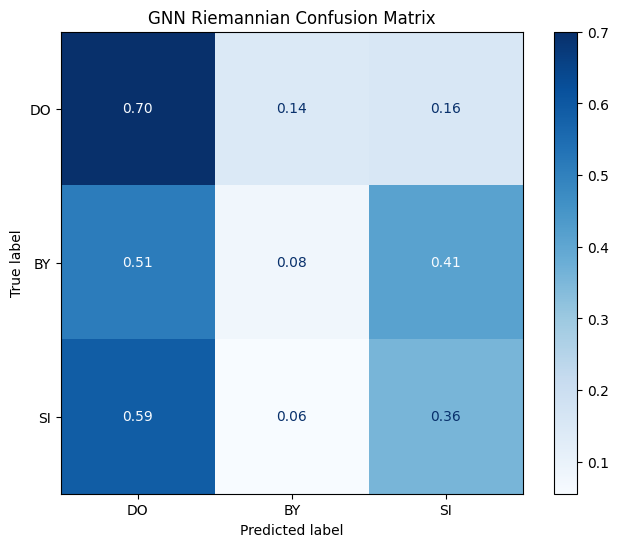


-- Runnning LOSO: Testing on S5
--- Testing Subject: S5 on cpu ---
Epoch 010 | Train Loss: 1.0844 | Val Loss: 1.1008 | Val Acc: 0.33
Epoch 020 | Train Loss: 1.0446 | Val Loss: 1.1203 | Val Acc: 0.37
Epoch 030 | Train Loss: 1.0018 | Val Loss: 1.2269 | Val Acc: 0.31
Epoch 040 | Train Loss: 0.9408 | Val Loss: 1.2275 | Val Acc: 0.33
Epoch 050 | Train Loss: 0.8994 | Val Loss: 1.3570 | Val Acc: 0.34
Epoch 060 | Train Loss: 0.8542 | Val Loss: 1.4104 | Val Acc: 0.34
Epoch 070 | Train Loss: 0.7991 | Val Loss: 1.5033 | Val Acc: 0.39
Epoch 080 | Train Loss: 0.7718 | Val Loss: 1.4860 | Val Acc: 0.38
Epoch 090 | Train Loss: 0.7233 | Val Loss: 1.6755 | Val Acc: 0.35
Epoch 100 | Train Loss: 0.6811 | Val Loss: 1.8111 | Val Acc: 0.33
🧐 Evaluating on test set...

✅ Evaluation Complete.
              precision    recall  f1-score   support

          DO       0.37      0.49      0.42        90
          BY       0.39      0.27      0.32        90
          SI       0.25      0.24      0.25        90

  

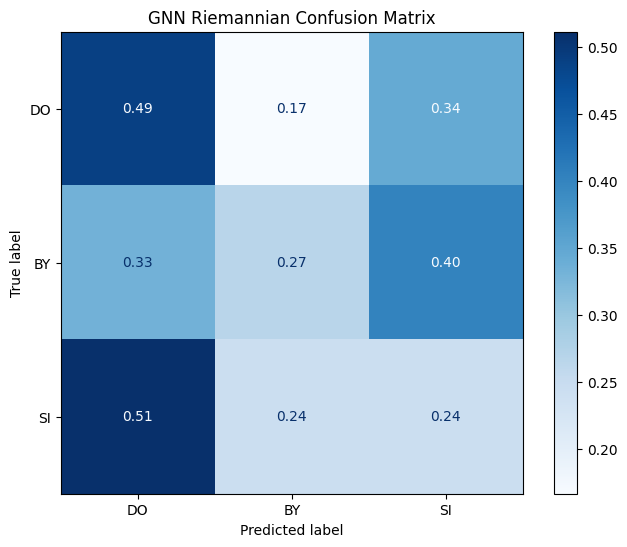


-- Runnning LOSO: Testing on S2
--- Testing Subject: S2 on cpu ---
Epoch 010 | Train Loss: 1.0893 | Val Loss: 1.1011 | Val Acc: 0.30
Epoch 020 | Train Loss: 1.0720 | Val Loss: 1.1277 | Val Acc: 0.31
Epoch 030 | Train Loss: 1.0453 | Val Loss: 1.2099 | Val Acc: 0.32
Epoch 040 | Train Loss: 1.0190 | Val Loss: 1.2588 | Val Acc: 0.31
Epoch 050 | Train Loss: 0.9955 | Val Loss: 1.2868 | Val Acc: 0.32
Epoch 060 | Train Loss: 0.9576 | Val Loss: 1.3095 | Val Acc: 0.28
Epoch 070 | Train Loss: 0.9196 | Val Loss: 1.3637 | Val Acc: 0.32
Epoch 080 | Train Loss: 0.8883 | Val Loss: 1.4523 | Val Acc: 0.33
Epoch 090 | Train Loss: 0.8639 | Val Loss: 1.3792 | Val Acc: 0.32
Epoch 100 | Train Loss: 0.8315 | Val Loss: 1.5514 | Val Acc: 0.30
🧐 Evaluating on test set...

✅ Evaluation Complete.
              precision    recall  f1-score   support

          DO       0.32      0.58      0.41        90
          BY       0.21      0.03      0.06        90
          SI       0.29      0.29      0.29        90

  

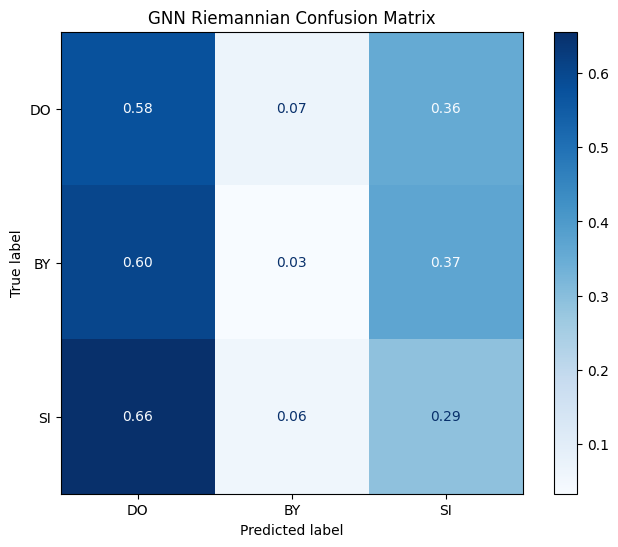


-- Runnning LOSO: Testing on S119
--- Testing Subject: S119 on cpu ---
Epoch 010 | Train Loss: 1.0921 | Val Loss: 1.0932 | Val Acc: 0.36
Epoch 020 | Train Loss: 1.0730 | Val Loss: 1.1032 | Val Acc: 0.32
Epoch 030 | Train Loss: 1.0480 | Val Loss: 1.1223 | Val Acc: 0.34
Epoch 040 | Train Loss: 1.0251 | Val Loss: 1.1456 | Val Acc: 0.33


KeyboardInterrupt: 

In [24]:
all_subjects = list(total_data.keys())
device = torch.device('cpu')

for test_sub in all_subjects:
    if test_sub == "S116":
        pass
    else:
        print(f"\n-- Runnning LOSO: Testing on {test_sub}")

        test_data = {test_sub: total_data[test_sub]}

        train_data = {s: total_data[s] for s in all_subjects if s != test_sub}

        model, test_loader = train_riemannian_gnn(train_data, test_data,test_sub)

        y_true, y_pred = evaluate_riemannian_gnn(model, test_loader, device)

    